                         Women clothing sentiment analysis
The objective of this notebook is to perform sentiment analysis on customer's feedback using deep learning  and extract key words/topics that define those reviews.

                  Table contents
1. Sentiment analysis
2. Importing packages & uploading our dataset
3. Checking duplicates 
4. Checking null values 
5. Descriptive statistics
6. Data visualisation 
7. Text preprocessing 
8. Feature engineering 
9. LSTM modelling & model prediction

                              Sentiment analysis

This is a natural language processing technique that uses computational linguistics and machine learning to detect the emotional tones behind textual data. In this notebook we will analyse  customer reviews on women clothes and prediction of the feelings/opinions behind those reviews.

Feelings will be categorized into positive, negative and neutral where;

Positive = Reviews where the consumer liked the product since it met his/her expectations.

Negative = Reviews where the product failed to met a consumer expectations.

Neutral = Reviews where the consumer felt the cloth was just okay.

i will use several python libraries specific to text analytics and machine learning. The cell below shows those libraries

In [ ]:
#import prequisite libararies
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords 
from nltk.stem.wordnet import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow.keras import layers, models 
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from sklearn.preprocessing import LabelBinarizer
import gensim 
from gensim import corpora 
from gensim.models import Phrases 
from gensim.models.phrases import Phraser

This dataset i have uploaded it from my local directory but one can access it from www.kaggle/datasets.com

In [ ]:
#uploading our dataset
df = pd.read_csv(r'/dataset/Womens Clothing E-Commerce Reviews.csv')
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [43]:
#shape of our dataset
df.shape

(23486, 11)

This dataset has 23,486 rows and 11 columns. Before doing further analysis I will rename columns to look more pythonic.

In [44]:
# rename columns to a more pythonic way
df.rename(columns={"Clothing ID": 'ID', 'Review Text':'Review', 'Recommended IND': 'Recommended_IND', 'Positive Feedback Count': 'Positive_Feedback_Count', 'Division Name': 'Division_Name', 'Department Name': 'Department_Name', 'Class Name': 'Class_Name'}, inplace=True)
df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
ID,767,1080,1077,1049,847
Age,33,34,60,50,47
Title,NaN,NaN,Some major design flaws,My favorite buy!,Flattering shirt
Review,Absolutely wonderful - silky and sexy and comf...,Love this dress! it's sooo pretty. i happene...,I had such high hopes for this dress and reall...,"I love, love, love this jumpsuit. it's fun, fl...",This shirt is very flattering to all due to th...
Rating,4,5,3,5,5
Recommended_IND,1,1,0,1,1
Positive_Feedback_Count,0,4,0,0,6
Division_Name,Initmates,General,General,General Petite,General
Department_Name,Intimate,Dresses,Dresses,Bottoms,Tops


                  Duplicated data

We will remove duplicates in our dataset since they may skew it making us to draw biased conclusions from it. Customer ID is a unique value so useful in removing duplicated values. The shape of our dataset after removing them will proof their existence or not.

In [45]:
# getting the dataset without duplicates by leveraging xor operator
df = df[~df['ID'].index.duplicated()]
df.shape

(23486, 11)

shape of our data remained the same thus our data didn't have duplicated values.

                   Checking null values

This will involve looking if there is null vallues in our dataset that may arise due to omissions, missimg values etc that may make it problematic to perform sentiment analysis.

In [46]:
#checking null values
df.isnull().sum()

Unnamed: 0                    0
ID                            0
Age                           0
Title                      3810
Review                      845
Rating                        0
Recommended_IND               0
Positive_Feedback_Count       0
Division_Name                14
Department_Name              14
Class_Name                   14
dtype: int64

There are various columns that have null values. We will fill all of them with empty space except review column which filter rows with empty reviews  since our analysis is based on it .

Then checking the shape of our dataset to confirm if we had applied the changes.

In [47]:
# filling these rows with empy space
df['Title'] = df['Title'].fillna('')
df['Department_Name'] = df['Department_Name'].fillna('')
df['Division_Name'] = df['Division_Name'].fillna('')
df['Class_Name'] = df['Class_Name'].fillna('')
# using xor expression to filter rows without any review
df = df[~df['Review'].isna()]

In [48]:
#confirming removal of null values
df.shape

(22641, 11)

In [49]:
#checking if there is any null values that have remained.
df.isnull().sum()

Unnamed: 0                 0
ID                         0
Age                        0
Title                      0
Review                     0
Rating                     0
Recommended_IND            0
Positive_Feedback_Count    0
Division_Name              0
Department_Name            0
Class_Name                 0
dtype: int64

                          Descriptive statistics

This will involve estimating various statistical  measures to our variables like mean, count, standard deviation, maximum value and minimum value and quantiles. The variables are the columns while the index is made up of the statistical parameters.

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,22641.0,11740.849035,6781.957509,0.0,5872.0,11733.0,17621.0,23485.0
ID,22641.0,919.332362,202.266874,1.0,861.0,936.0,1078.0,1205.0
Age,22641.0,43.280376,12.326980,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.183561,1.115762,1.0,4.0,5.0,5.0,5.0
Recommended_IND,22641.0,0.818868,0.385136,0.0,1.0,1.0,1.0,1.0
Positive_Feedback_Count,22641.0,2.630582,5.786164,0.0,0.0,1.0,3.0,122.0


                      Data Visualization

This refers to using charts, graphs etc to identify patterns, relationships in raw data thus making it easy to understand and communcate to others who arent familiar with technical details. Below are charts that expound on how our reviews are distributed, frequency of words and their relevance.

we will convert numerical ratings into groups named Good, negative and neutral where:

Good = are those reviews with ratings greater than 3 i.e rating 4 and 5,

Neutral = Reviews with ratings equal to 3,

Negative = Reviews with ratings less than 3 i.e rating 2 and 1.

In [51]:
# a function to convert ratings into clusters namely Good, Neutral, Negative
def rating(score):
    if score > 3:
        return 'Good'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Bad'


Text(0.5, 1.0, 'Rating Distribution Across Dataset\nAfter Transformation')

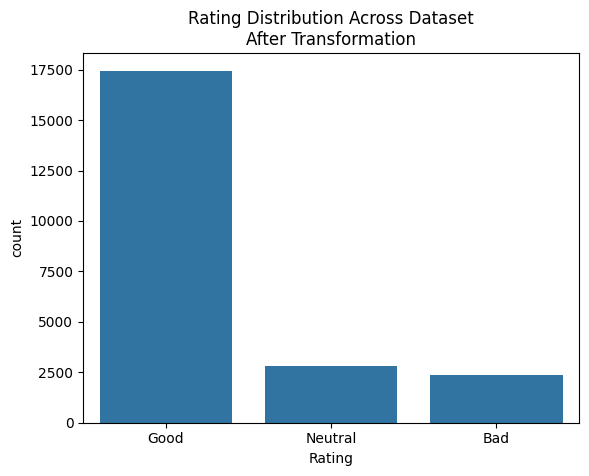

In [52]:
# applying  the function to our rating
df['Rating'] = df['Rating'].apply(rating)
ax = sns.countplot(data=df, x='Rating')
ax.set_title('Rating Distribution Across Dataset\nAfter Transformation')

Reviews rated good are the highest close to 17,500 entries indicating strong overall consumer satisfaction and maybe brand affinity among the shoppers,  followed with neutral with 3000 entries while reviews rated 'Bad' had the lowest entries at less than 2,500 showing that dissatisfaction among consumers was relatively low at the aggregate level.


In [53]:
#converting review column datatype from object to string
df['Review'] = df['Review'].apply(str)

                   Distribution of reviews

<Figure size 1000x700 with 0 Axes>

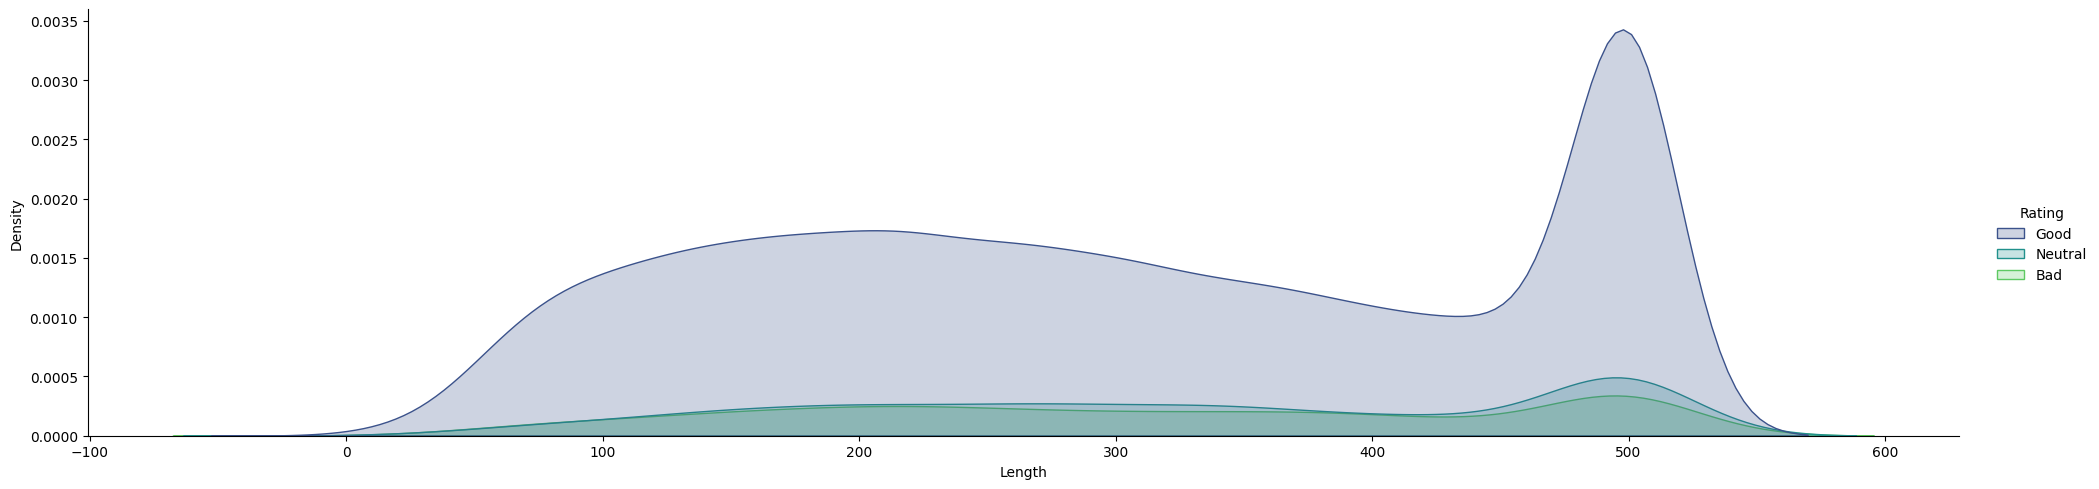

In [54]:
df['Length'] = df['Review'].apply(len)
plt.figure(figsize=(10, 7))
ax = sns.displot(data=df, x='Length', hue='Rating', kind='kde', aspect=4, fill=True, palette='viridis')

The length of reviews are highly right-skewed with most reviews averaging 200 words. The distribution shows a strong peak around 500 words and a long tail extending toward 600 words thus signifying much longer reviews.  This suggest while most users had reviews around 200 words, small number of users had significant, longer reviews. 
If we take the ratings by category, the distributiona are largely overlapping in shape showing that the length of the reviews is not a stong indicator of its rating i.e Good, Neutral or Bad.

Displaying the review with the highest positive feedback

In [55]:
max_feedback = df['Positive_Feedback_Count'].max()
print(df[df['Positive_Feedback_Count']== max_feedback].iloc[0]['Review'])

I loved the lace detailing all over this dress and the fact it had pockets and was mostly cotton. it just looked so inviting, so i grabbed two sizes to try on (10 & 12) that 99% of the time fit me with retailer clothes. here are my thoughts:
__________
pros:
- lace detailing is lovely all over.
- everything runs tts except at the bust (see below).
- breathable fabric, comfortable.
_________
cons:
- i'm a 36c and could not button the top two buttons of this dress in a size 10 (i'm 5'9, hourglass, a


      Mean positive feedback review

Text(2.6, -0.2, 'Mean: 2.63')

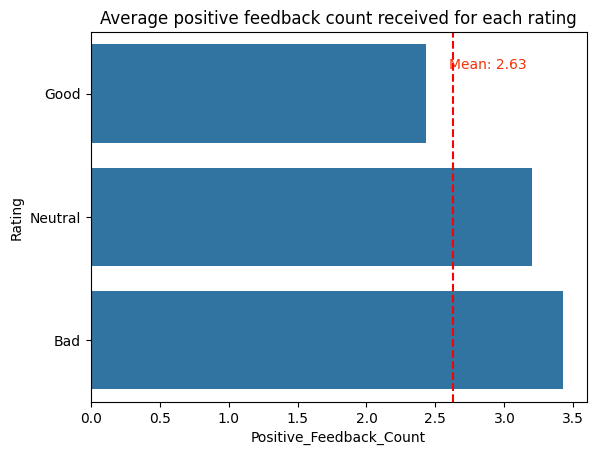

In [56]:
mean_feedback = df['Positive_Feedback_Count'].mean()
ax = sns.barplot(data=df, y='Rating', x='Positive_Feedback_Count', orient='h', errorbar=None)
ax.set_title('Average positive feedback count received for each rating')
plt.axvline(mean_feedback, color='red', ls='--')
plt.text(x=2.6, y=-0.2, s='Mean: ' + str(round(mean_feedback, 2)), color="#f33207",)


The average positive feedback count is relatively consistent across all rating categories hovering around the overall mean of 2.63. Reviews rated 'Good' received average positive feedback count sligtly below overall mean while reviews rated ' Neutral & Bad' received positive feedback count sligtly above the mean with 'Bad' rated reviews receiving the average positive feedback.

          conclusion
This suggest most shoppers are engaging with neutral or negative reviews than with positive ones. This may be due to product flaws or customer service issues that resonate with others shoppers.

         WordCloud

This  is a visual representation of textual data which offers high-level overview of topics or key themes  with the most common and frequent words being larger and bolder in colour to signify their importance.

Below is a wodcloud for reviews rated 'Good".

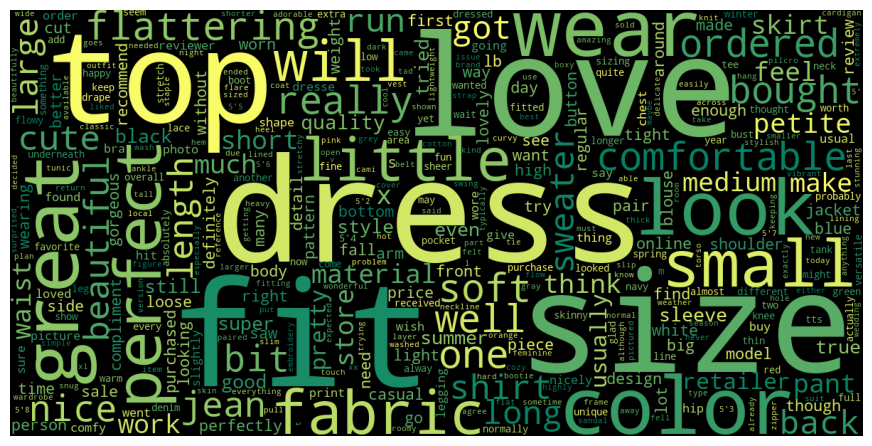

In [ ]:
good = df[df['Rating'] == 'Good']['Review']
plt.figure(figsize=(11, 11))
wc = WordCloud(max_words=1000, min_font_size=10, height=600, width=1200, collocations=False, background_color='black', colormap='summer').generate(
    ''.join(good)
)
plt.axis('off')
plt.imshow(wc)


Below is a function of showing the most frequent words in reviews rated good

In [58]:
# a function to show frequent words
def top_words(text):
    word = pd.DataFrame(wc.process_text("".join(text)).items()).sort_values(by=1, ascending=False)
    print('Top 6 frequent words {text} wordcloud')
    for i in range(6):
        item = word.iloc[i]
        print(item[0] + '\t--> ' + str(item[1]))

In [59]:
#frequent words in reviews rated good
top_words(good)

Top 6 frequent words {text} wordcloud
fit	--> 8204
dress	--> 8008
love	--> 7546
size	--> 7527
top	--> 6200
color	--> 5599


           Wordcloud for reviews rated Neutral

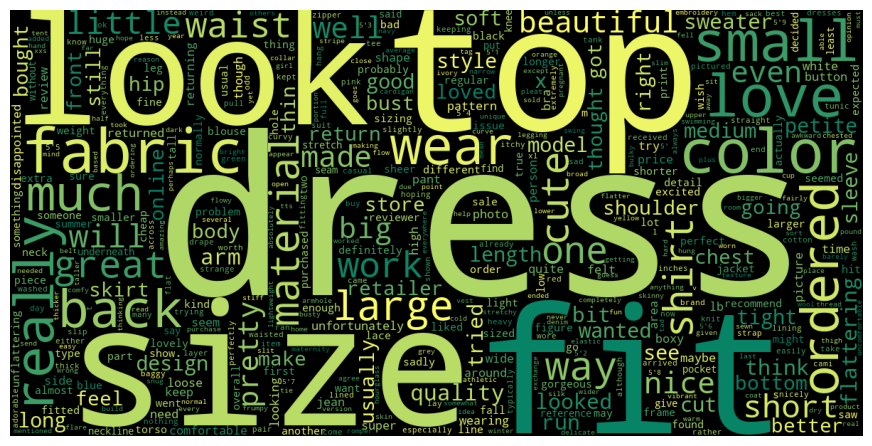

In [60]:

neutal = df[df['Rating'] == 'Neutral']['Review']
plt.figure(figsize=(11, 11))
wc = WordCloud(max_words=1000, min_font_size=10, height=600, width=1200, collocations=False, background_color='black', colormap='summer').generate(
    ''.join(neutal)
)
plt.axis('off')
plt.imshow(wc)

In [61]:
top_words(neutal)

Top 6 frequent words {text} wordcloud
dress	--> 1400
top	--> 1239
fit	--> 1177
size	--> 1115
look	--> 1023
fabric	--> 830


            Wordcloud for reviews rated Bad

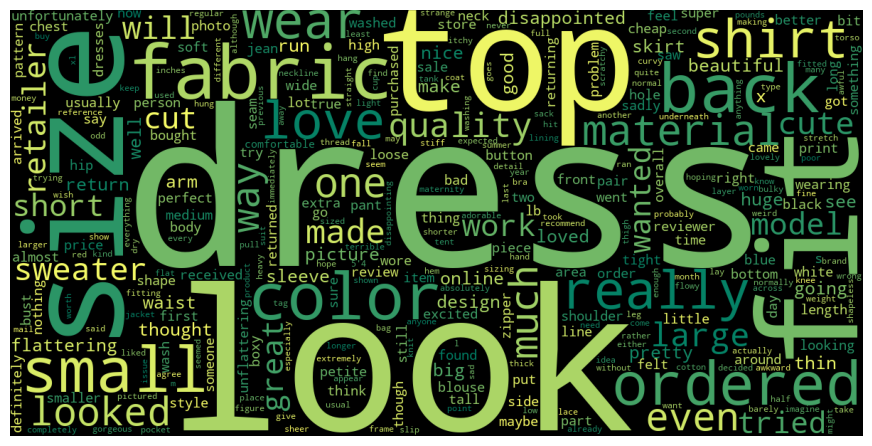

In [62]:
bad = df[df['Rating'] == 'Bad']['Review']
plt.figure(figsize=(11, 11))
wc = WordCloud(max_words=1000, min_font_size=10, height=600, width=1200, collocations=False, background_color='black', colormap='summer').generate(
    ''.join(bad)
)
plt.axis('off')
plt.imshow(wc)

In [63]:
top_words(bad)

Top 6 frequent words {text} wordcloud
dress	--> 1120
look	--> 911
top	--> 903
size	--> 769
fit	--> 769
fabric	--> 725


We will remove other columns are remain with columns like Review, Rating and DepartName which are valuable for carrying out sentiment analysis.

In [64]:
# selecting review, Rating and DepartmentName columns
df = df[['Review', 'Rating',  'Department_Name']]
df.head()

,Review,Rating,Department_Name
0,Absolutely wonderful - silky and sexy and comf...,Good,Intimate
1,Love this dress! it's sooo pretty. i happene...,Good,Dresses
2,I had such high hopes for this dress and reall...,Neutral,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",Good,Bottoms
4,This shirt is very flattering to all due to th...,Good,Tops


                Text preprocessing

This is a process that consists a series of steps of wrangling, cleaning and standardized textual data into a form that could be fed into machine learning or deep learning models.

It involves techniques like: removing stopwords, case conversions, cleaning text to remove non-alphanumeric characters, tokenization(dividing sentences into words or phrases) and lemmatization (converting words into their root form e.g walking, walked etc into walk)

In [65]:
# a function to preprocess text
def preprocessText(text):
    #removing non-alphanumericcharacters
    text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    #removing stopwords
    cleaned_text = [w for w in text.split() if w not in stopwords.words('english')]
    corpus = []
    for w in cleaned_text:
        #converting words into their root word
        lemmatizer = WordNetLemmatizer()
        corpus.append(lemmatizer.lemmatize(w))
    return ' '.join(corpus)

In [66]:
# applying our function to our revies
df['Review'] = df['Review'].apply(preprocessText)

Below is a sample of cleaned text

In [67]:
#sample of a cleaned text
df['Review'][0]

'absolutely wonderful silky sexy comfortable'

             Train-Test-Split

This is a machine learning technique that divides dataset into training and testing sets to evaluate how well a model generalizes on new data. Training set is used to train the model while the testing set is for assessing model performance.

Reviews will be our x variable while y variable will be Ratings with our training taking 80% of the whole dataset.

In [68]:
#splitting our dataset into training and testing data
x_train, x_test, y_train, y_test = train_test_split(df['Review'], df['Rating'], test_size=0.2)

               Text preprocessing and vectorization

Before building the model, further text preprocessing and vectorization will be needed thus it will need this steps:

1. Tokenizer = initialzing a tokenizer with num-words capping them to 10,000 words and setting 'oov_token' to 'OOV' for words found in test dataset but were not in training dataset.

2. Sequencing and padding: This involves converting words or strings into integers a process called vectorization and then adding zeros to sentences that varry in length to ensure they have the same dimension before being fed to the model.

3. Label Management: This will involve transforming categorical labels that is 'Neutral, Bad, Good' into a one-hot encoded format


In [ ]:
max_len = 63
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)
total_word = len(tokenizer.word_index)
train_seq = tokenizer.texts_to_sequences(x_train)
train_padded = pad_sequences(train_seq, maxlen=max_len) 
test_seq = tokenizer.texts_to_sequences(x_test)
test_padded = pad_sequences(test_seq, maxlen=max_len)
lb = LabelBinarizer()
train_labels = lb.fit_transform(y_train)
test_labels = lb.transform(y_test)


                    LSTM model

Long short-term memory (LSTM) is a deep learning architecture that is a subtype of
recurent neural network(RNN) which is adapted to processing sequences of data. LSTM addresses the problem of short-term memory in RNN by adding the cell state. This
allows for past information to flow through the network for a longer period of time,
meaning that the network still carries information from early values in the sequence.

The LSTM is made up of three gates:

 1.The forget gate determines what information from past steps is still relevant.

 2.The input gate determines what information from the current step is relevant.

 3.The output gate determines what information is passed on to the next element of the sequence or as a result to the output layer.

This function below implements the LSTM model, This will involve:
1. Embedding layer that maps the tokens into a 32-dimensional vector
2. Bidirectional LSTm that helps the model to process the text both forwards and backwards thus helping the model to learn a word meaning by capturing what comes before or behind it. 
3. Attention Layers that hellp the model to focus on specific important words rather than treat each word with equal importance.
4. The regularizers and Droput helps the model by preventing the model from overfitting thus forcing the model to generalise better. 

Then i will compile the model thus it learns by iteratively adjusting its internal parameters to map text into correct categories. The parameters are optimizers like Adam, loss like categorical entropy etc

In [ ]:
inputs = layers.Inputs(shape=(63,))
x = layers.Embedding(total_word, 32)(inputs)
lstm_out = layers.Bidirectional(layers.LSTM(16, return_sequences=True))(x)
attention_layers = layers.Dense(1, activation='tanh')(lstm_out)
attention_layers = layers.Flatten()(attention_layers)
attention_layers =  layers.activation('softmax')(attention_layers)
attention_layers = layers.RepeatVector(32)(attention_layers)
attention_layers = layers.Permute([2, 1])(attention_layers)
sent_rep = layers.Multiply()[lstm_out, attention_layers]
sent_rep = layers.Lambda(x: tf.reduce_sum(x, axis=1))(sent_rep)

In [ ]:

inputs = layers.Input(shape=(63,))
x = layers.Embedding(total_word, 32)(inputs)
lstm_out = layers.Bidirectional(layers.LSTM(16, return_sequences=True))(x)
attention_weights = layers.Dense(1, activation='tanh')(lstm_out)
attention_weights = layers.Flatten()(attention_weights)
attention_weights = layers.Activation('softmax')(attention_weights)
attention_weights = layers.RepeatVector(32)(attention_weights)
attention_weights = layers.Permute([2, 1])(attention_weights)
sent_representation = layers.Multiply()([lstm_out, attention_weights])
sent_representation = layers.Lambda(lambda x : tf.reduce_sum(x, axis=1))(sent_representation)
x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(sent_representation)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 63)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 63, 32)    │    503,424 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 63, 32)    │      6,272 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 63, 1)     │         33 │ bidirectional_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 63)        │          0 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 63)        │          0 │ flatten_8[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_8     │ (None, 32, 63)    │          0 │ activation_8[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_6 (Permute) │ (None, 63, 32)    │          0 │ repeat_vector_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 63, 32)    │          0 │ bidirectional_8[… │
│ (Multiply)          │                   │            │ permute_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 32)        │          0 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 32)        │      1,056 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 3)         │         99 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 510,884 (1.95 MB)

 Trainable params: 510,884 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

         Model compiling 

Finally we compile the model by using Adam optimizerwhich is best due to adaptive learning, 'categorical_crossentropy' to penalize the model and using accuracy as a metric which acts as a measure for a model performance.

To avoid over-fitting, I will implement early stopping. It stops the model if it starts to overfit by monitoring model's performance of the validation data at each iteration and if the loss starts to increase or accuracy decreasing, it stops after 3 consecutive epochs. 

In [80]:
#model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(train_padded, train_labels, epochs=20, validation_data=(test_padded, test_labels), callbacks=[early_stop])

Epoch 1/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 97s 144ms/step - accuracy: 0.7846 - loss: 0.6924 - val_accuracy: 0.8055 - val_loss: 0.4960
Epoch 2/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 74s 130ms/step - accuracy: 0.8185 - loss: 0.4547 - val_accuracy: 0.8077 - val_loss: 0.4553
Epoch 3/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.8325 - loss: 0.4089 - val_accuracy: 0.8125 - val_loss: 0.4583
Epoch 4/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.8423 - loss: 0.3829 - val_accuracy: 0.8123 - val_loss: 0.4898
Epoch 5/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.8515 - loss: 0.3552 - val_accuracy: 0.8154 - val_loss: 0.5044


     Plotting model performance

Below is a plot showing model performance i.e accuracy, val_accuracy, loss and val_loss as the model was being trained

<Axes: >

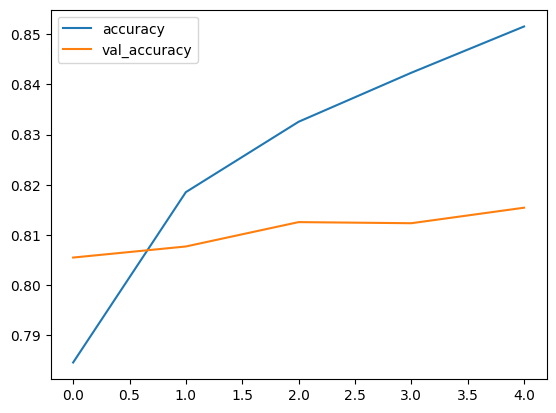

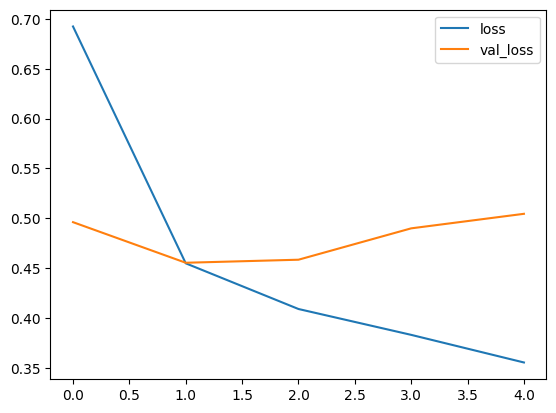

In [81]:
model_metrics = pd.DataFrame(model.history.history)
model_metrics[['accuracy', 'val_accuracy']].plot()
model_metrics[['loss', 'val_loss']].plot()

                               Predictions
Below is a function that will predict whether a review is 'Bad', 'Neutral', or 'Good' and the probabilities of how bad, good or neutral a review is. 

This will involve preprocessinbg the text by vectorizing it, padding it thus making them of uniform length, predicting it and getting the probabilities of a sentiment.

In [82]:
import numpy 
def predict_sentiment(text):
    sequences = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequences, maxlen=max_len)
    prediction = model.predict(padded)
    label_map = lb.classes_
    result = label_map[np.argmax(prediction)]
    confidence = np.max(prediction) * 100 
    print(f'Review: {text}')
    print(f'Sentiment: {result} ({confidence:.2f}% confidence)\n')
test_reviews = ['This dress is absolutely stunning and fits perfectly!',
                'The fabric felt cheap and it arrived with a hole in the sleeve',
                'It is a basic t-shirt.Nothing special, but itdoes the job',
                'I wanted to love this, but the sizing is completely off']

for review in test_reviews:
    predict_sentiment(review)



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Review: This dress is absolutely stunning and fits perfectly!
Sentiment: Good (98.79% confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
Review: The fabric felt cheap and it arrived with a hole in the sleeve
Sentiment: Bad (51.92% confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Review: It is a basic t-shirt.Nothing special, but itdoes the job
Sentiment: Good (78.63% confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
Review: I wanted to love this, but the sizing is completely off
Sentiment: Bad (42.77% confidence)



             Topic Modelling 
This involves the process of extracting key themes/ concepts from textual data thus getting hidden latent-relationship between terms. This will help us to get thoughts, opinions and granular understanding of a review.

I will focus on bad reviews and implement Latent DirichletAllocation(LDA) to extract themes in the reviews. The recurring themes will be bigrams meaning  2 words to give context of a review.



In [ ]:


bad_reviews = df[df['Rating'] == 'Bad']['Review'].astype(str).tolist()
tokenized_reviews = [[word for word in str(review).lower().split() if word.isalpha() and len(word)> 2] for review in bad_reviews]
phrases = Phrases(tokenized_reviews, min_count=1, threshold=1)
bigram_model = Phraser(phrases)
data_with_bigram = [bigram_model[doc] for doc in tokenized_reviews]
dictionary = corpora.Dictionary(tokenized_reviews)
custom_words = ['dress', 'would', 'top', 'shirt', 'look', 'skirt', 'really', 'wear', 'back',
                'item', 'like', 'fit', 'size']
data_final = [[w for w in doc if w not in custom_words] for doc in data_with_bigram]
corpus = [dictionary.doc2bow(text) for text in data_final]
num_topics = 3 
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes=20)
for idx, topic in lda_model.print_topics(-1):
    print(f'topic {idx}: {topic}')

topic 0: 0.011*"sweater" + 0.010*"fabric" + 0.008*"returned" + 0.007*"color" + 0.006*"return" + 0.006*"sleeve" + 0.005*"one" + 0.005*"love" + 0.005*"ordered" + 0.004*"also"
topic 1: 0.007*"material" + 0.006*"fabric" + 0.006*"cut" + 0.006*"also" + 0.006*"flattering" + 0.006*"big" + 0.006*"small" + 0.005*"tried" + 0.005*"work" + 0.005*"arm"
topic 2: 0.007*"way" + 0.007*"one" + 0.007*"disappointed" + 0.007*"retailer" + 0.006*"even" + 0.005*"small" + 0.005*"ordered" + 0.005*"sure" + 0.005*"zipper" + 0.004*"much"


                     Topic 0 
This topic involves words like sweater, fabric, returned, color meaning the clothes were not of good quality as described thus unsatisfying the customer prompting their return

                Topic 1 
Words like material, fabric, cut and flattering in this topic  focus more on aesthetics and fitting thus the complaints are about how the cloth is made or how it looks after being worn.

            Topic 2 
This topic having words like dissapointed, retailer,small, ordered and zipper showing clothes effect on their customers, sizing issues, complains in clothes not being like the one ordered and 'Zipper' showing problems with the clothes itself.

NB: Topic 0and Topic 1 have some overlaps and by reducing the counts of terms or the threshold didn't result in bigrams.

End of our notebook, our model performed well as it have categorized reviews into right categories

                  References 

https://medium.com/analytics-vidya/lstms-explained-a-complete-technically-accurate-conceptual-guide-with-keras--2a650327e852

Time Series forecasting by Marcos Pexeira

Text analytics by Dipanjan Sarkar


